# 06 - Explainability, prioritisation and CLV proxy
**Questions:** why does the model flag a customer, and whom should the company contact first?

> Explanations describe how the **model** reaches a score. They do **not** show what causes a customer to leave.

In [1]:
import sys, json, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import Markdown, display
from src.config import *
from src import eda, evaluation as ev
from src.feature_engineering import *
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

In [2]:
customers = pd.read_csv(DATA_PROC / "customers_clean.csv", parse_dates=["customer_registration_date"])
tx = pd.read_csv(DATA_PROC / "transactions_clean.csv.gz", parse_dates=["date"])
orders = build_orders(tx); lines, returns = tx[~tx.is_return], tx[tx.is_return]
M = json.load(open(DATA_PROC / "metrics.json")); H = M["H"]
meta = json.load(open(DATA_PROC / "run_metadata.json"))
START, END = pd.Timestamp(M["data_start"]), pd.Timestamp(M["data_end"])
FEATURES_USED = meta["features_used"]
train_c = [pd.Timestamp(c) for c in M["train_cutoffs"]]; val_c = pd.Timestamp(M["val_cutoff"]); test_c = pd.Timestamp(M["test_cutoff"])
display(Markdown(f"> **Dataset: {meta['name']}** ({'SIMULATED' if meta['kind'] == 'synthetic' else 'real'}) | {M['data_start']} -> {M['data_end']} | churn window **{H} days** ({M['churn_window_source']}). "
                 "All numbers in the commentary below are computed from this dataset when the notebook runs."))

> **Dataset: online_retail_ii** (real) | 2009-12-01 -> 2011-12-09 | churn window **180 days** (P95 of purchase gaps = 221 days, rounded up to a multiple of 15). All numbers in the commentary below are computed from this dataset when the notebook runs.

In [3]:
import shap
from src.churn_model import load
from src import explainability as xai
model = load("churn_model.joblib"); feats = json.load(open(DATA_PROC / "model_config.json"))["features"]
print("selected model:", meta["model_selected"], "| features:", feats)
test = build_snapshot(orders, lines, returns, customers, test_c, H, data_end=END).reset_index()
X, y = test[feats], test.churned
sv, base = xai.shap_values(model, X)
# SHAP must reproduce the model: base value + sum of contributions = the model's own log-odds
logit = np.log(model.predict_proba(X)[:, 1] / (1 - model.predict_proba(X)[:, 1]))
print("max |base + sum(SHAP) - model log-odds| =", float(np.abs(base + sv.sum(1) - logit).max()))
gi = xai.global_importance(sv, X); perm = pd.read_csv(DATA_PROC / "permutation_importance_test.csv")
display(pd.concat([gi.head(8), perm.head(8)], axis=1))

selected model: Gradient boosting | features: ['recency_days', 'frequency', 'monetary', 'aov', 'purchase_frequency_30d', 'days_since_first_order', 'avg_gap_days', 'gap_std_days', 'gap_cv', 'recency_to_gap_ratio', 'orders_30d', 'orders_90d', 'orders_prev90d', 'frequency_change', 'spend_90d', 'spend_prev90d', 'spend_change', 'active_months', 'n_unique_products', 'avg_units_per_order', 'return_rate']


max |base + sum(SHAP) - model log-odds| = 5.329070518200751e-15


,feature,mean_abs_shap,feature,pr_auc_drop,std
0,active_months,0.345631,active_months,0.027655,0.004334
1,monetary,0.320259,monetary,0.016124,0.007076
2,recency_to_gap_ratio,0.235196,spend_90d,0.011455,0.001259
3,n_unique_products,0.192142,avg_gap_days,0.009303,0.007412
4,frequency,0.145875,n_unique_products,0.009157,0.007336
5,return_rate,0.140634,return_rate,0.007061,0.003220
6,spend_90d,0.129032,gap_cv,0.006793,0.005496
7,gap_cv,0.113888,frequency,0.005267,0.001365


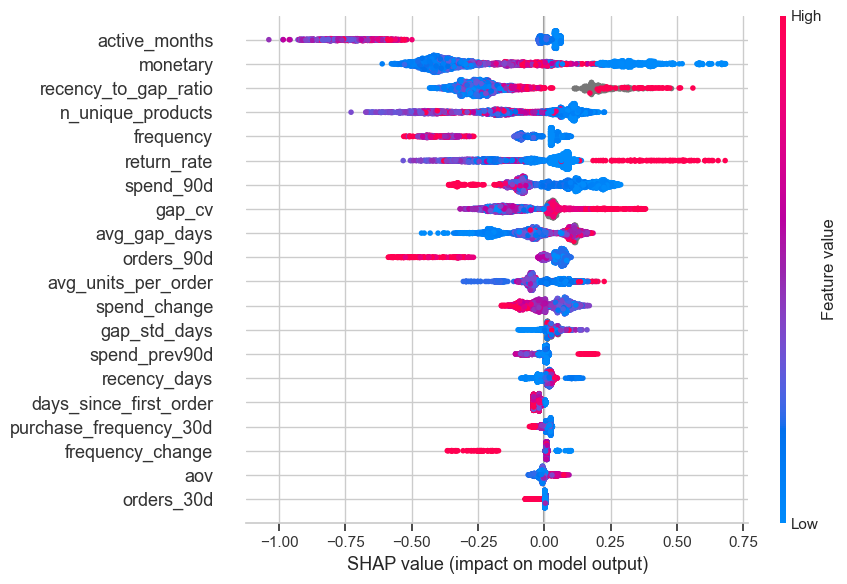

In [4]:
shap.summary_plot(sv, X, show=False, plot_size=(9, 6)); plt.show()

In [5]:
top_shap, top_perm = gi.feature.iloc[0], perm.feature.iloc[0]
display(Markdown(f"""**Reading the importances.** SHAP ranks `{top_shap}` first; permutation importance (drop in test PR-AUC when a feature is shuffled) ranks `{top_perm}` first. Agreement between two independent methods increases confidence; disagreement is a reason to look closer.
Features that share information (frequency, 90-day orders, spend...) split the credit among themselves. Importances describe what the *model* uses on *this* dataset; they are not universal laws and not causes."""))

**Reading the importances.** SHAP ranks `active_months` first; permutation importance (drop in test PR-AUC when a feature is shuffled) ranks `active_months` first. Agreement between two independent methods increases confidence; disagreement is a reason to look closer.
Features that share information (frequency, 90-day orders, spend...) split the credit among themselves. Importances describe what the *model* uses on *this* dataset; they are not universal laws and not causes.

## Individual explanations

Highest-risk customer: 12845 | churn probability 67% | actual outcome: churned
  Factors increasing risk:
   + 354 total spend
   + silent 11.3x longer than their usual gap
   + irregular ordering rhythm (variation 1.39)
  Factors reducing risk:
   - average order value of 89
   - 4 orders placed so far
   - 1.09 orders per 30 days of life

A low-risk customer: 17389 | churn probability 3% | actual outcome: retained
  Factors increasing risk:
   + irregular ordering rhythm (variation 1.41)
   + order spacing varies by 19 days
   + average order value of 744
  Factors reducing risk:
   - bought in 15 different months
   - 7 orders in the last 90 days
   - 41 orders placed so far



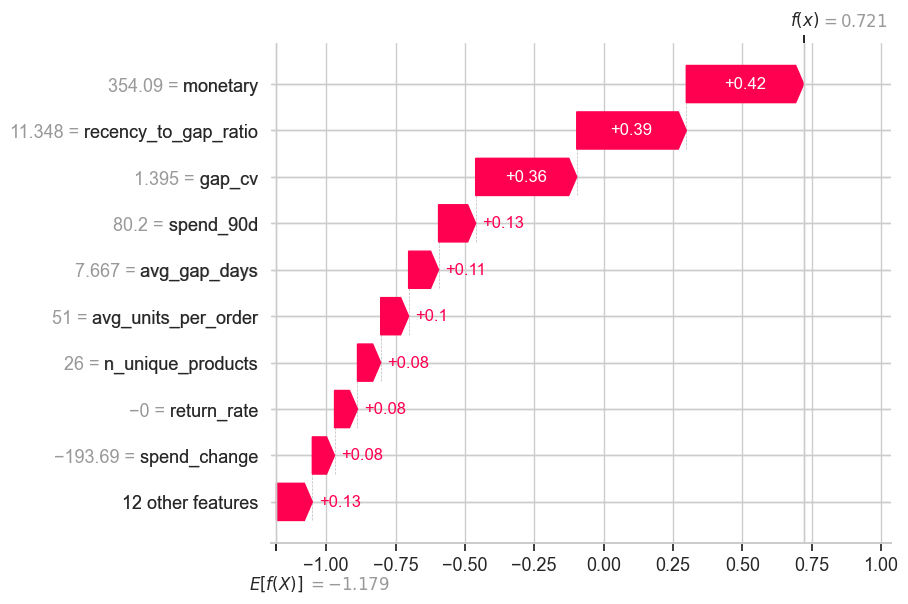

In [6]:
p = model.predict_proba(X)[:, 1]
for label, i in [("Highest-risk customer", int(np.argmax(p))), ("A low-risk customer", int(np.argsort(p)[len(p)//10]))]:
    up, down = xai.explain_row(sv[i], X.iloc[i], 3)
    print(f"{label}: {test.customer_id[i]} | churn probability {p[i]:.0%} | actual outcome: {'churned' if y.iloc[i] else 'retained'}")
    print("  Factors increasing risk:"); [print("   +", s) for s in up]
    print("  Factors reducing risk:");   [print("   -", s) for s in down]; print()
shap.plots.waterfall(shap.Explanation(sv[int(np.argmax(p))], base, X.iloc[int(np.argmax(p))].to_numpy(), feature_names=feats), show=False); plt.show()

## Prioritisation: risk x value
Churn probability alone is not a plan. Two High-risk customers with very different annual value deserve different responses. The playbook below maps (risk tier, value tier) to a *suggested* action. It supports a human decision, it does not make it.

In [7]:
from src.prioritization import PLAYBOOK, WINBACK
cs = pd.read_csv(DATA_PROC / "customers_scored.csv.gz")
pb = pd.DataFrame([(r, v, *a) for (r, v), a in PLAYBOOK.items()], columns=["risk", "value", "priority", "action"]); display(pb)
act = cs[cs.status == "Active"]
display(pd.crosstab(act.risk_level, act.value_tier).reindex(index=["High","Medium","Low"], columns=["High","Medium","Low"]))
summary = act.groupby("priority").agg(customers=("customer_id", "size"), expected_margin_at_risk=("margin_at_risk", "sum"), mean_churn_prob=("churn_prob", "mean")).round(2); display(summary)

,risk,value,priority,action
0,High,High,P1 - Critical,Personal outreach: customer-service call or ac...
1,High,Medium,P2 - High,Personalised email with product recommendation...
2,High,Low,P3 - Low-cost,Automated reminder email / 'we miss you' messa...
3,Medium,High,P2 - High,"Loyalty communication (early access, thank-you..."
4,Medium,Medium,P3 - Low-cost,Automated reminder or product-recommendation e...
5,Medium,Low,P4 - Monitor,Keep in regular newsletter; re-score next month
6,Low,High,P5 - Maintain,Loyalty / VIP communication; do NOT discount (...
7,Low,Medium,P5 - Maintain,Business-as-usual communication
8,Low,Low,P5 - Maintain,Business-as-usual communication


value_tier,High,Medium,Low
risk_level,,,
High,0,25,54
Medium,713,975,339
Low,1074,288,6


,customers,expected_margin_at_risk,mean_churn_prob
priority,,,
P2 - High,738,158205.23,0.17
P3 - Low-cost,1029,61023.43,0.25
P4 - Monitor,339,9450.39,0.29
P5 - Maintain,1368,51370.41,0.03


## CLV proxy - assumptions stated plainly
`clv_12m_proxy = annual margin run-rate x average survival over the next 12 months`, where run-rate = historical spend / observed life (at least 90 days) x 365, margin = a flat assumed share of revenue (`business.gross_margin` in the config, shown in the banner of the dashboard), and the model's churn probability for one H-day window is assumed constant in each future window. This is a **heuristic**. A rigorous CLV would use a probabilistic purchase model (e.g. BG/NBD + Gamma-Gamma) validated on a hold-out period.

In [8]:
top = act.sort_values("priority_score", ascending=False).head(10)[["customer_id","rfm_segment","churn_prob","risk_level","annual_margin_run_rate","clv_12m_proxy","margin_at_risk","priority"]]
display(top.round(2))
p1 = act[act.priority.str.startswith("P1")]
display(Markdown(f"""**So what?** Of {len(act):,} active customers, **{len(p1)}** are both High-risk and High-value (P1) with ~{p1.margin_at_risk.sum():,.0f} of expected annual margin at stake: compare this with the size of the other groups to judge whether personal outreach is feasible. Lower-value groups get automated, low-cost messages. {int((act.risk_level=='Low').sum()):,} Low-risk customers are deliberately **left alone**: contacting them wastes budget and discounting them gives away margin."""))

,customer_id,rfm_segment,churn_prob,risk_level,annual_margin_run_rate,clv_12m_proxy,margin_at_risk,priority
4037,16446,Loyal customers,0.41,Medium,89988.97,33895.49,37273.36,P2 - High
3596,16000,Champions,0.50,Medium,15079.00,4367.61,7572.76,P2 - High
5703,18139,Champions,0.28,Medium,10266.65,5491.22,2892.85,P2 - High
397,12752,Potential loyalists,0.40,Medium,5312.92,2092.72,2115.98,P2 - High
2801,15195,New customers,0.43,Medium,4697.55,1696.15,2015.24,P2 - High
335,12688,Potential loyalists,0.42,Medium,4722.85,1764.88,1969.39,P2 - High
106,12454,Champions,0.32,Medium,4281.11,2083.91,1365.99,P2 - High
475,12830,Champions,0.27,Medium,4363.76,2422.20,1163.96,P2 - High
5083,17509,Champions,0.15,Medium,7401.76,5393.40,1111.23,P2 - High
3625,16029,Champions,0.07,Medium,16420.64,14341.23,1086.87,P2 - High


**So what?** Of 3,474 active customers, **0** are both High-risk and High-value (P1) with ~0 of expected annual margin at stake: compare this with the size of the other groups to judge whether personal outreach is feasible. Lower-value groups get automated, low-cost messages. 1,368 Low-risk customers are deliberately **left alone**: contacting them wastes budget and discounting them gives away margin.